In [1]:
import polars as pl
import json
import matplotlib.pyplot as plt
import os 
import numpy as np 
from math import pi, sin, cos, sqrt

from post_process_parquet import calculate_dataframe

%matplotlib widget

In [ ]:
data1 = calculate_dataframe("2026_10_2_9h54")
data2 = calculate_dataframe("2026_10_2_11h34")
data3 = calculate_dataframe("2026_10_2_11h43")
data4 = calculate_dataframe("2026_10_2_11h47")



In [ ]:
data5 = calculate_dataframe("2026_9_8_10h23")

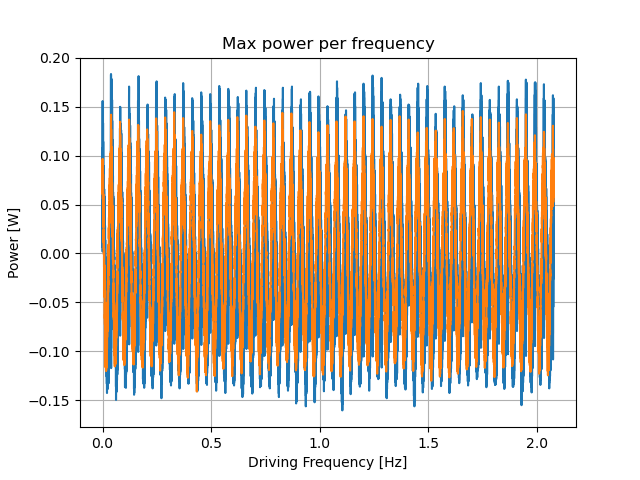

In [31]:
plt.figure()
plt.plot(data5["time_meas"][2], data5["acc1_temp"][2])
plt.plot(data5["time_meas"][2], data5["acc2_temp"][2])
plt.xlabel("Driving Frequency [Hz]")
plt.ylabel("Power [W]")
plt.title("Max power per frequency")
plt.grid()
plt.show()

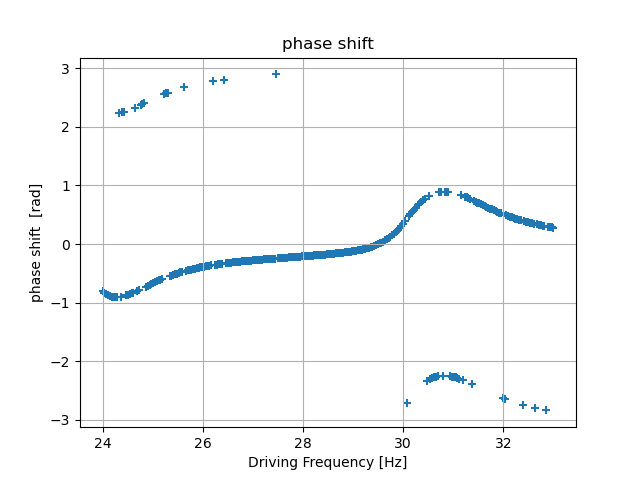

In [32]:
plt.figure()
plt.scatter(data5["f"], data5["phase_shift"], marker='+')
plt.xlabel("Driving Frequency [Hz]")
plt.ylabel("phase shift  [rad]")
plt.title("phase shift")
plt.grid()
plt.show()

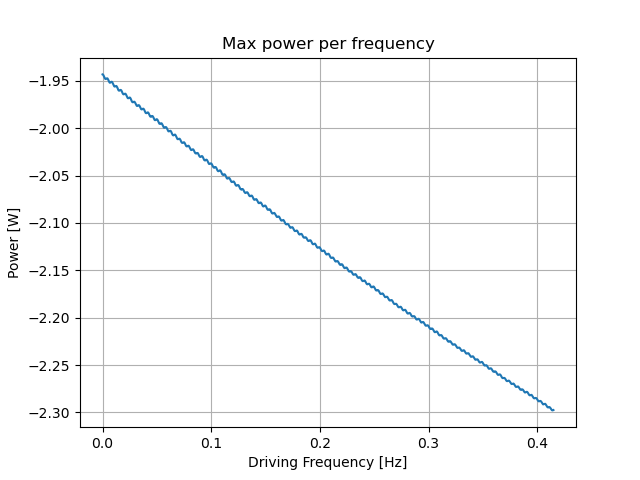

In [10]:
plt.figure()
plt.plot(data1["time_meas"][2], data1["err_mean"][2])
plt.xlabel("Driving Frequency [Hz]")
plt.ylabel("Power [W]")
plt.title("Max power per frequency")
plt.grid()
plt.show()

In [18]:
test = data1.group_by(
    pl.col("f")
).agg(
    pl.col("pow1").max(),
    pl.col("phase_shift")
)

In [24]:
np.transpose(test["phase_shift"])[0]

array([-1.34801365,  1.34824736, -0.40118087, -0.78240293,  0.06627243,
        0.56703509,  1.80944375, -0.23917575,  1.08156057,  1.79726989,
       -0.57356591,  2.18355942, -0.6269622 ,  2.69111572,  0.13960333])

ValueError: setting an array element with a sequence.

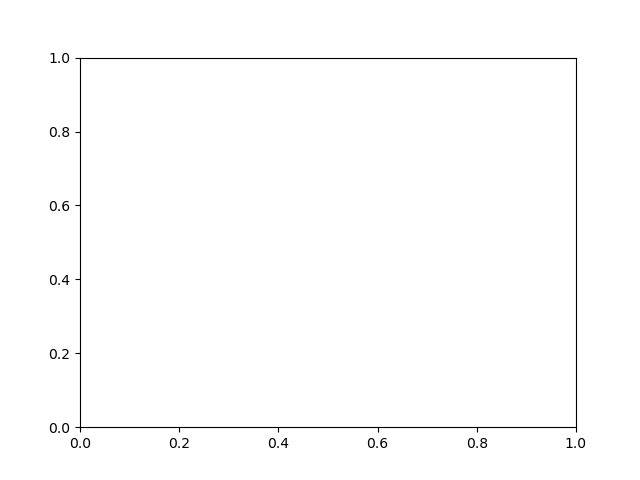

In [15]:
plt.figure()
plt.scatter(test["f"], test["err_mean"], marker='+')
plt.xlabel("Driving Frequency [Hz]")
plt.ylabel("Power [W]")
plt.title("Max power per frequency")
plt.grid()
plt.show()